In [5]:
import pandas as pd 
import numpy as np
import json
import matplotlib.pyplot as plt

In [6]:
# Best result model path
path_val_results = "../Results/Safetorch/GraphSAGE_noCRoss_sisampler_f1score/analyzed_validation_results.csv"

In [7]:
# Read the CSV file into a DataFrame
df = pd.read_csv(path_val_results)

In [8]:
# Or Load hyperparameters from manually set values
hidden_dim = 16
learning_rate = 0.1
epochs = 10
dropout = 0.1
batch_size = 64
#n_heads = 4
weight_decay = 0.01

In [9]:
# Filter the data based on specific hyperparameters
mask = (df['hidden_dim'] == hidden_dim) & (df['dropout'] == dropout) & \
        (df['epochs'] == epochs )  & \
        (df['learning_rate'] == learning_rate ) & \
        (df['batch_size'] == batch_size) &  (df['weight_decay'] == weight_decay)# & \
       # (df['num_heads'] == n_heads) # Comment / Uncomment for GAT / GCN

# Filter the DataFrame based on the mask
filtered_df = df[mask]

In [10]:
filtered_df.head()

,filename,name,address,node_shape,edge_shape,true_label,prediction,parser_probability,dataset_len,hidden_dim,dropout,learning_rate,epochs,batch_size,weight_decay,num_heads
386326,example_3_32.pt,sym.deregister_tm_clones,0x80492c0,"(5, 100)","(2, 5)",0,0,0.270489,653,16,0.1,0.1,10,64,0.01,1
386327,example_3_32.pt,sym.register_tm_clones,0x8049300,"(5, 100)","(2, 5)",0,0,0.253482,653,16,0.1,0.1,10,64,0.01,1
386328,example_3_32.pt,sym.__do_global_dtors_aux,0x8049340,"(5, 100)","(2, 4)",0,0,0.187454,653,16,0.1,0.1,10,64,0.01,1
386329,example_3_32.pt,sym.frame_dummy,0x8049370,"(6, 100)","(2, 6)",0,0,0.373241,653,16,0.1,0.1,10,64,0.01,1
386330,example_3_32.pt,sym.json_parse_string,0x8049430,"(30, 100)","(2, 44)",1,1,0.589929,653,16,0.1,0.1,10,64,0.01,1


In [11]:
df_count = filtered_df.groupby(['name', 'dataset_len'],as_index=False).agg({'prediction':'count'}).reset_index()
df_count.head()

,index,name,dataset_len,prediction
0,0,main,252,10
1,1,main,294,28
2,2,main,382,28
3,3,main,653,28
4,4,main,679,28


In [12]:
df_predictions = filtered_df.groupby(['name', 'dataset_len'])['prediction'].value_counts().unstack(fill_value=0).reset_index()
df_predictions.head()

prediction,name,dataset_len,0,1
0,main,252,0,10
1,main,294,0,28
2,main,382,0,28
3,main,653,0,28
4,main,679,2,26


In [13]:
merged_df = pd.merge(df_predictions, df_count , on=['name', 'dataset_len'], how='inner')
merged_df.drop('index', axis=1, inplace=True)
merged_df.head()

,name,dataset_len,0,1,prediction
0,main,252,0,10,10
1,main,294,0,28,28
2,main,382,0,28,28
3,main,653,0,28,28
4,main,679,2,26,28


In [14]:
merged_df['ratio_0'] = merged_df[0] / merged_df['prediction']
merged_df['ratio_1'] = merged_df[1] / merged_df['prediction']
merged_df['max'] = merged_df[['ratio_0', 'ratio_1']].max(axis=1)
merged_df.head()

,name,dataset_len,0,1,prediction,ratio_0,ratio_1,max
0,main,252,0,10,10,0.000000,1.000000,1.000000
1,main,294,0,28,28,0.000000,1.000000,1.000000
2,main,382,0,28,28,0.000000,1.000000,1.000000
3,main,653,0,28,28,0.000000,1.000000,1.000000
4,main,679,2,26,28,0.071429,0.928571,0.928571


In [15]:
# Set up matplotlib for better aesthetics
plt.rcParams["mathtext.fontset"]
plt.rcParams.update({'font.size': 24, 'font.family': 'STIXGeneral', 'mathtext.fontset': 'stix'})

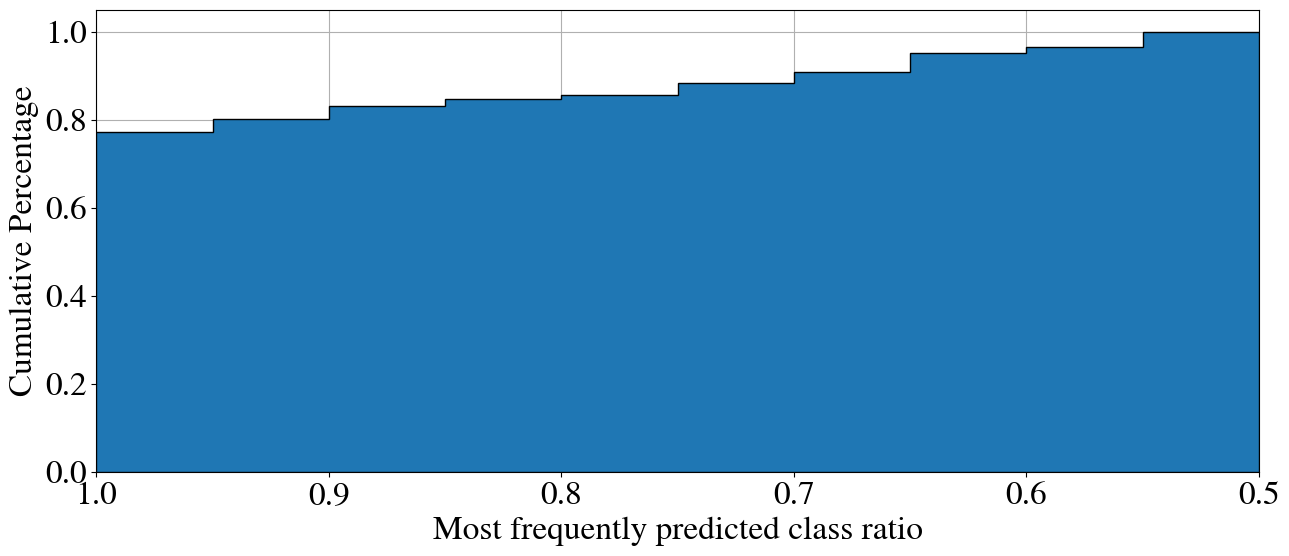

In [16]:
weights = np.ones_like(merged_df['max']) / len(merged_df['max'])
plt.figure(figsize=(15,6))
plt.hist(merged_df['max'], bins=10, edgecolor='black', cumulative=-1, weights=weights,zorder=3,histtype='stepfilled')
plt.xlim(1, 0.5)
plt.xlabel('Most frequently predicted class ratio')
plt.ylabel('Cumulative Percentage')
plt.grid(True, zorder=0)
# plt.title('Cumulative Distribution of Max Ratio (1 to 0.5)')
plt.show()

In [17]:
df_mapping = pd.DataFrame(
    {'Validation parser': 
        [
            'PicoHTTPParser', 'CSimpleJSONParser', 'Benoitc_HTTP', 
            'CParserXML', 'CJSON', 'YACC_Calculator',
            'ELF_Parser', 'Network_Packet_Analyzer', 'Packcc', 'PCAP_Parser'
        ],
    'dataset_len':[760, 653, 421, 362, 2293, 252, 679, 382, 1802, 294],})
                           

# PicoHTTPParser      760
# CSimpleJSONParser   653
# Benoitc_HTTP        421
# CParserXML          362
# CJSON               2293   
# YACC_Calculator     252
# ELF_Parser          679
# Network_Packet_Analyzer 382
# Packcc             1802
# PCAP_Parser         294

In [18]:
merged_df = pd.merge(merged_df, df_mapping, on='dataset_len', how='inner')
merged_df.head()

,name,dataset_len,0,1,prediction,ratio_0,ratio_1,max,Validation parser
0,main,252,0,10,10,0.0,1.0,1.0,YACC_Calculator
1,sym.__do_global_dtors_aux,252,10,0,10,1.0,0.0,1.0,YACC_Calculator
2,sym._init,252,10,0,10,1.0,0.0,1.0,YACC_Calculator
3,sym.computeSymbolIndex,252,10,0,10,1.0,0.0,1.0,YACC_Calculator
4,sym.deregister_tm_clones,252,10,0,10,1.0,0.0,1.0,YACC_Calculator


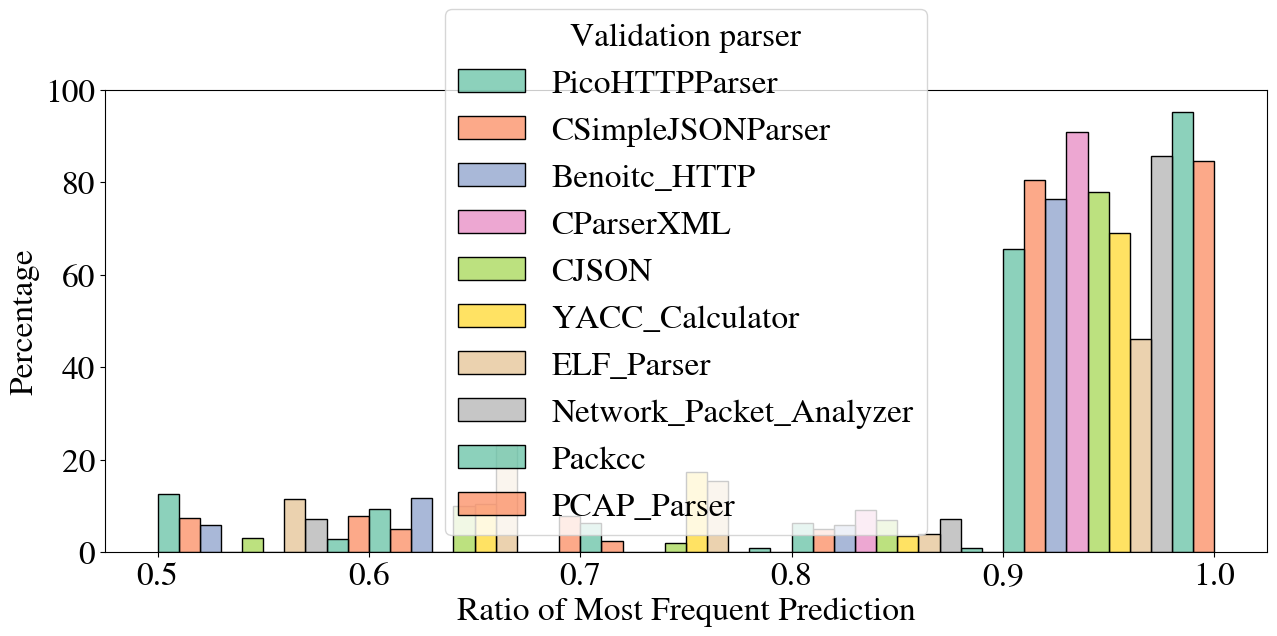

<Figure size 640x480 with 0 Axes>

In [19]:
import seaborn as sns
# import matplotlib.pyplot as plt

# Set the figure size
plt.figure(figsize=(15, 6))

# Compute the weights for each 'dataset_len' group
weights = merged_df.groupby('Validation parser')['max'].transform(lambda x: 100 / len(x))
hue_order = [
    'PicoHTTPParser', 'CSimpleJSONParser', 'Benoitc_HTTP', 
    'CParserXML', 'CJSON', 'YACC_Calculator', 
    'ELF_Parser', 'Network_Packet_Analyzer', 'Packcc', 'PCAP_Parser'
]
# Plot the distribution of 'max' for each 'dataset_len' with a colorblind-friendly palette
sns.histplot(data=merged_df, x='max', hue='Validation parser', multiple='dodge',
              bins=5, edgecolor='black', weights=weights, palette='Set2',
              hue_order=hue_order)

# Set the labels and title
plt.xlabel('Ratio of Most Frequent Prediction')
plt.ylabel('Percentage')
# plt.title('Distribution of Max Ratio for Each Dataset Length')

# Legend
# plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15),
#            ncol=3, fontsize='small')

# Show the plot
plt.show()
# Show the plot
plt.tight_layout()  # Adjust layout to prevent clipping

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


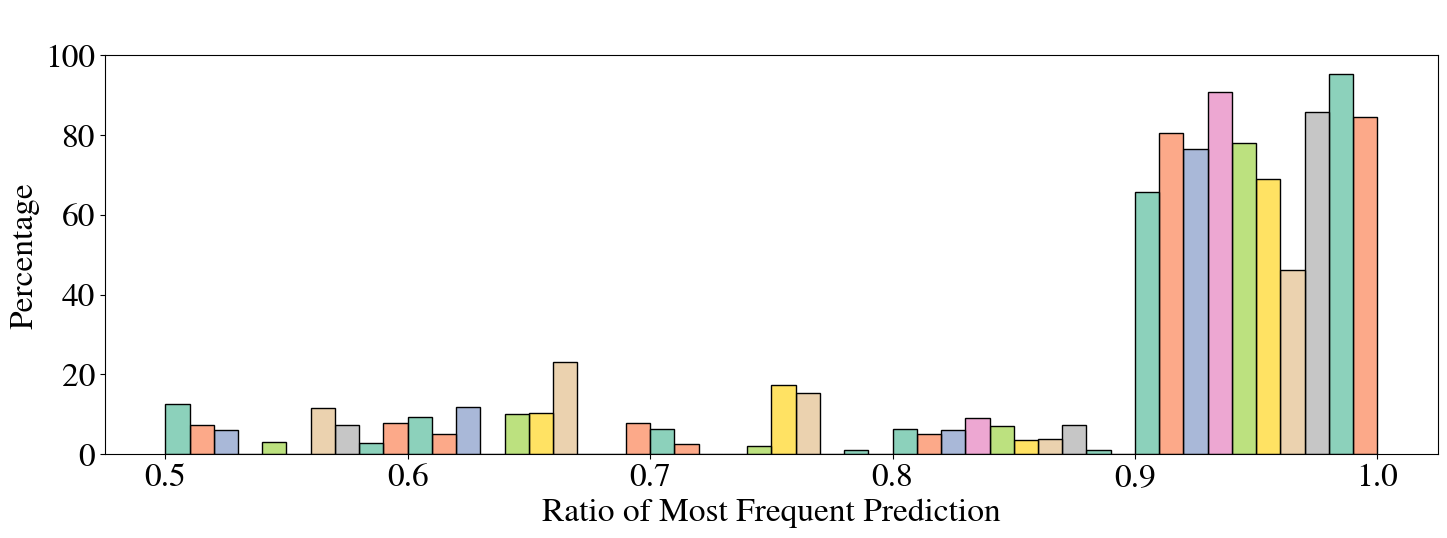

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the figure size
plt.figure(figsize=(15, 6))

# Compute the weights for each 'Validation parser' group
weights = merged_df.groupby('Validation parser')['max'] \
                   .transform(lambda x: 100 / len(x))

hue_order = [
    'PicoHTTPParser', 'CSimpleJSONParser', 'Benoitc_HTTP', 
    'CParserXML', 'CJSON', 'YACC_Calculator', 
    'ELF_Parser', 'Network_Packet_Analyzer', 'Packcc', 'PCAP_Parser'
]

# Plot the distribution
sns.histplot(
    data=merged_df,
    x='max',
    hue='Validation parser',
    multiple='dodge',
    bins=5,
    edgecolor='black',
    weights=weights,
    palette='Set2',
    hue_order=hue_order
)

# Labels
plt.xlabel('Ratio of Most Frequent Prediction')
plt.ylabel('Percentage')

# Horizontal legend on top
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, 1.15),
    ncol=3,
    fontsize='small',
    frameon=False
)

# Tweak layout & show
plt.tight_layout()
plt.show()

/tmp/ipykernel_533500/918395609.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = merged_df.groupby(['Validation parser', 'max_bin']).size().unstack(fill_value=0)


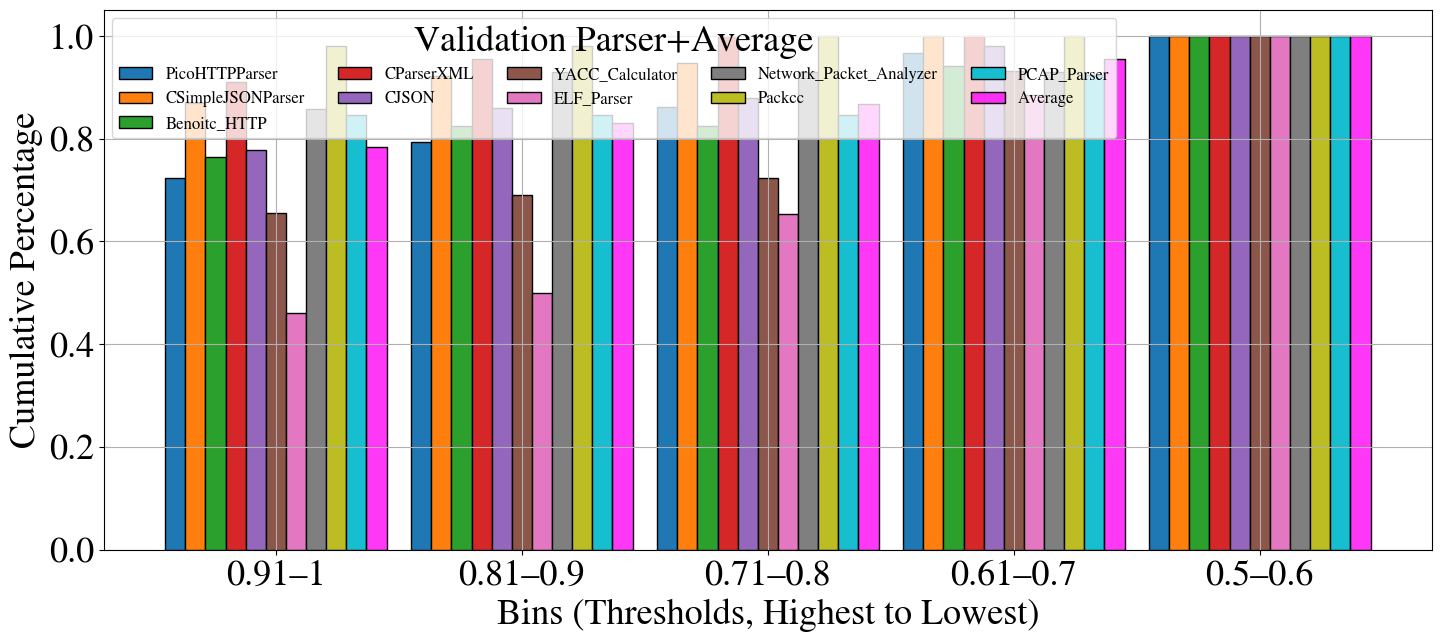

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


plt.rcParams["mathtext.fontset"]
plt.rcParams.update({'font.size': 26, 'font.family': 'STIXGeneral', 'mathtext.fontset': 'stix'})

# Example dataframe:
# df = pd.DataFrame({
#     'Validation parser': ['A', 'A', 'A', 'B', 'B', 'B', 'B'],
#     'max': [0.05, 0.12, 0.78, 0.95, 0.33, 0.86, 0.23]
# })

# 1. Define bins (0.1 increments)
bins = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
bin_labels = ["0.5–0.6", "0.61–0.7", "0.71–0.8", "0.81–0.9", "0.91–1"]

# 2. Assign each 'max' value to a bin
merged_df['max_bin'] = pd.cut(merged_df['max'], bins=bins, labels=bin_labels, right=True, include_lowest=False)

# 3. Compute frequency counts per Validation parser and per bin
counts = merged_df.groupby(['Validation parser', 'max_bin']).size().unstack(fill_value=0)

# 4. Convert counts to percentage frequencies within each Validation parser
row_sums = counts.sum(axis=1)
freqs = counts.div(row_sums, axis=0)

# 5. Compute reverse cumulative distribution
# Reverse the bin order to start from the highest bin
reversed_bins = bin_labels[::-1]
freqs_reversed = freqs[reversed_bins]
reverse_cum = freqs_reversed.cumsum(axis=1)

# Now reverse_cum has Validation parser as rows, and bins in descending order as columns
# Each cell is the cumulative proportion of values >= that bin’s lower boundary.

# 6. Transpose so bins are the rows (x-axis) and Validation parser are columns
plot_data = reverse_cum.T

plot_data = plot_data[hue_order]

plot_data['Average'] = plot_data.mean(axis=1)

# Reorder columns if you want the "Average" bar at the end or another position
# For example, put it at the end:
columns_order = hue_order + ['Average']
plot_data = plot_data[columns_order]

# 8. Choose seaborn palette for the Validation Parsers and then add a distinct color for Average
# For N parsers + 1 average column:
parser_count = len(hue_order)
colors = sns.color_palette("pastel6", n_colors=parser_count)
colors.append('black')  # Use black (or another distinct color) for Average

ax = plot_data.plot(kind='bar', figsize=(15,7), edgecolor='black', width=0.9)

avg_container = ax.containers[-1]

# now recolor *only* those bars:
for bar in avg_container:
    bar.set_color("#FF00F7C7")      # color fill
    bar.set_edgecolor('#000000')    # black edges
    #bar.set_hatch('xx')              # crosshatch

ax.set_xlabel("Bins (Thresholds, Highest to Lowest)")
ax.set_ylabel("Cumulative Percentage")
#ax.legend(title="Validation Parser+Average",loc='upper left',fontsize=14, ncol=2)
ax.legend(title="Validation Parser+Average", loc='upper left', fontsize=12, ncol=5)
plt.grid()
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('percentage_bars.png')
plt.show()